In [29]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib import cm
from numpy.linalg import svd
from mpl_toolkits.mplot3d import Axes3D
import helpers as stopinf
from time import time
from scipy.linalg import svd

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# %% 0.15vpp

input_name = '0p15vpp'

letters = [chr(c) for c in range(ord('a'), ord('j')+1)]
num_files = len(letters)

base_path = '/disk/hyk049/DHM_new_1Dcenter/'

first_file = f'{base_path}Q_1D_{input_name}_a.h5'

with h5py.File(first_file, 'r') as f:
    t = f['/t'][:].T
    x = f['/x'][:].T

nx = len(x)

# Preallocate list
Q_1D = []

# Read all files
for letter in letters:
    filename = f'{base_path}Q_1D_{input_name}_{letter}.h5'
    with h5py.File(filename, 'r') as f:
        Q = f['/Q_1D'][:].T
    Q_1D.append(Q.T)
    

In [8]:
# Split samples

split_size = 5760
num_segs = len(t) // split_size
tt = t[:split_size]

num_signals = len(Q_1D)

# (nx, num_segs * num_signals, split_size)
Qstate_all = np.zeros((nx, num_segs*num_signals, split_size))

for s in range(num_signals):

    Q_experiment = Q_1D[s][:, :split_size*num_segs]

    for k in range(num_segs):

        idx_start = k*split_size
        idx_end = (k+1)*split_size

        col_idx = s*num_segs + k

        Q_temp = Q_experiment[:, idx_start:idx_end]

        Qstate_all[:, col_idx, :] = Q_temp

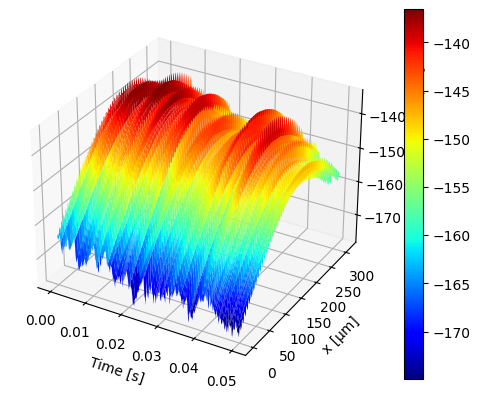

In [18]:
# Plot expected dynamics

Q_mean = np.mean(Qstate_all, axis=1)

T, X = np.meshgrid(tt, x)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

surf = ax.plot_surface(T, X, Q_mean, cmap='jet', linewidth=0, antialiased=True)

ax.set_xlabel('Time [s]')
ax.set_ylabel('x [μm]')
ax.set_zlabel('Surface displacement [μm]')

plt.colorbar(surf)
plt.show()

In [24]:
# from scipy.signal import butter, filtfilt

# # %% Filter signals

# FS_DHM = 115200
# fc = 1e4

# # Design 4th-order Butterworth LPF
# Wn = fc / (FS_DHM / 2)
# b, a = butter(4, Wn, btype='low')

# # Reshape to 2D for fast filtering
# nx, Nsamp, Nt = Qstate_all.shape

# Q_reshaped = Qstate_all.reshape(nx * Nsamp, Nt)

# # Zero-phase filtering along time dimension
# Q_filtered = filtfilt(b, a, Q_reshaped, axis=1)

# # Reshape back to 3D
# Qstate_filtered = Q_filtered.reshape(nx, Nsamp, Nt)

# # %% Plot expected dynamics (filtered)

# Q_mean_filtered = np.mean(Qstate_filtered, axis=1)

# T, X = np.meshgrid(tt, x)

# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')

# surf = ax.plot_surface(T, X, Q_mean_filtered, cmap='jet', linewidth=0)

# ax.set_xlabel('Time [s]')
# ax.set_ylabel('x [μm]')
# ax.set_zlabel('Surface displacement [μm]')

# plt.colorbar(surf)
# plt.show()

In [ ]:
# Get POD basis

print("Computing subspace Vr...")

V, S, _ = svd(Qstate_all.reshape(nx, -1), full_matrices=False)

print("Subspace computation complete!")

Computing subspace Vr...
Subspace computation complete!


In [26]:
# Stochastic OpInf

# max r value
rmax = 20

h = float(tt[1] - tt[0])
_, L, s = Qstate_all.shape

seed_test = 42

# FOM expectation (average) over all samples
EFOM = np.mean(Qstate_all, axis=1)
# EFOM = np.mean(Qstate_filtered, axis=1)

# Testing noise sample numbers
L_test = L * np.array([1])

In [27]:
# input signal
f_input = 7e6
u_amp = 1

u_train = u_amp * np.cos(2 * np.pi * f_input * tt)

In [ ]:
# Test with fixed u_amp, sigma + regularization

# Regularization grids
A_reg = np.logspace(-1, 3, 10)
B_reg = np.logspace(0, 8, 10)
N_reg = np.logspace(0, 5, 10)

# Optimal ROM dimension
r_opt = 13

# Dimensions
nx, L, s = Qstate_all.shape
isbilinear = False
seed_test = 42

# FOM expectation
EFOM = np.mean(Qstate_all, axis=1)   # shape (nx, s)

# Choose outer loop based on bilinear or linear ROM
outerLoop = range(len(N_reg)) if isbilinear else range(len(A_reg))
ROM_form = "non-autonomous bilinear ROM" if isbilinear else "non-autonomous linear ROM"

# Initialization
EROM = [None] * len(A_reg)
CROM = [None] * len(B_reg)
E_error = np.zeros((len(A_reg), len(B_reg)))
C_error = np.zeros((len(A_reg), len(B_reg)))

# Seed random numbers
np.random.seed(seed_test)

for ii in outerLoop:
    start_time = time.time()
    print(f"{ii+1}th A_reg")

    EROM[ii] = [None] * len(B_reg)
    CROM[ii] = [None] * len(B_reg)

    for jj in range(len(B_reg)):

        # Regularization vector
        lam = [1, B_reg[jj], N_reg[ii]] if isbilinear else [A_reg[ii], B_reg[jj], 1]

        # --- Drift OpInf ---
        Ehatr, Ahatr, Bhatr, Nhatr = stopinf.infer_drift_u(E_train, u_train, h, isbilinear, lam)

        # --- Diffusion OpInf ---
        Mhatr, Khatr = stopinf.infer_diffusion_u(C_train, u_train, h, Ahatr, Nhatr)

        # Fixed sigma
        sigma = 100

        # ROM function using Wiener process
        def fhatr(x0, u, Ls):
            if x0.ndim == 1:
                x0 = x0[:, None]  # (r,1)
            noise = np.sqrt(h) * Mhatr @ np.random.randn(Mhatr.shape[1], Ls)
            B = x0 + h*Bhatr*u + noise
            return np.linalg.solve(Ehatr - h*Ahatr - h*Nhatr*u, B)

        # ROM basis and initial condition
        Vr_temp = V[:, :r_opt]
        xr0 = Vr_temp.T @ EFOM[:, 0]

        # ROM simulation
        Eopinf, Copinf = stopinf.compute_model_u(fhatr, Vr_temp, xr0, u_train, L, L)

        # Reconstruct FOM
        E_recon = Vr_temp @ Eopinf

        EROM[ii][jj] = E_recon
        CROM[ii][jj] = Copinf

        # Compute errors
        E_error[ii, jj] = np.linalg.norm(E_train - Eopinf, ord='fro') / np.linalg.norm(E_train, ord='fro')
        C_error[ii, jj] = stopinf.page_norm(C_train - Copinf) / stopinf.page_norm(C_train)

    print(f"Elapsed time: {time.time() - start_time:.2f} s")

# Pack errors
error = {
    "E_error": E_error,
    "C_error": C_error
}